# 0. Import Libraries

In [5]:
# Import relevant libraries
import yfinance as yf
import pandas as pd
import numpy as np
import random
import scipy.stats as stats
import statsmodels.api as sm
# Plotting Library
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
# Import acf & pacf plotting functions
from scipy.stats import norm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import acf, pacf
# Import tests
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_breusch_godfrey
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import acorr_ljungbox
# Import ARIMA
# from arch import arch_model
# Use the lzip to pretty-print short descriptions for the test returns
from statsmodels.compat import lzip
# Import ignore
import warnings
warnings.filterwarnings('ignore')

# 1. Data Description

## Data Loaded

In [8]:
start = "2014-01-01"
end   = "2024-12-31"

# Download price data from Yahoo Finance
# Brent Crude Oil Futures (North Sea benchmark)
oil = yf.download("BZ=F", start=start, end=end, auto_adjust=False)["Adj Close"]

# Oslo Stock Exchange All-Share Index (OSEAX)
ose = yf.download("^OSEAX", start=start, end=end, auto_adjust=False)["Adj Close"]

# FTSE 100 Index (London Stock Exchange)
ftse = yf.download("^FTSE", start=start, end=end, auto_adjust=False)["Adj Close"]

# S&P 500 Index (US Equity Benchmark)
sp500 = yf.download("^GSPC", start=start, end=end, auto_adjust=False)["Adj Close"]

# -------------------------------------------------------
# Interest rate (Norway) – use 10-Year Government Bond Yield as proxy
rate = yf.download("^TNX", start=start, end=end, auto_adjust=False)["Adj Close"]

# Convert all series to monthly frequency using last observation of each month
oil_m   = oil.resample("M").last()
ose_m   = ose.resample("M").last()
ftse_m  = ftse.resample("M").last()
sp500_m = sp500.resample("M").last()
rate_m  = rate.resample("M").last()

# Combine all price-level series into a single dataframe
df = pd.concat([oil_m, ose_m, ftse_m, sp500_m, rate_m], axis=1)
df.columns = ["oil_price", "ose_price", "ftse_price", "sp500_price", "rate_level"]

# Compute log returns for all variables
df["oil_ret"]    = np.log(df["oil_price"] / df["oil_price"].shift(1))
df["ose_ret"]    = np.log(df["ose_price"] / df["ose_price"].shift(1))
df["ftse_ret"]   = np.log(df["ftse_price"] / df["ftse_price"].shift(1))
df["sp500_ret"]  = np.log(df["sp500_price"] / df["sp500_price"].shift(1))

# Interest rate return (change in interest rate, not return)
df["rate_change"] = df["rate_level"].diff()

# Drop missing observations
df = df.dropna()

df.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,oil_price,ose_price,ftse_price,sp500_price,rate_level,oil_ret,ose_ret,ftse_ret,sp500_ret,rate_change
Date,,,,,,,,,,
2014-02-28,109.070000,611.770020,6809.700195,1859.449951,2.658,0.024784,0.034743,0.044947,0.042213,-0.010
2014-03-31,107.760002,622.190002,6598.399902,1872.339966,2.723,-0.012083,0.016889,-0.031521,0.006908,0.065
2014-04-30,108.070000,643.200012,6780.000000,1883.949951,2.648,0.002873,0.033210,0.027150,0.006182,-0.075
2014-05-31,109.410004,675.140015,6844.500000,1923.569946,2.457,0.012323,0.048464,0.009468,0.020812,-0.191
2014-06-30,112.360001,690.390015,6743.899902,1960.229980,2.516,0.026606,0.022337,-0.014807,0.018879,0.059


## Descriptive Statistics

In [10]:
desc_stats = df.describe()
desc_stats

,oil_price,ose_price,ftse_price,sp500_price,rate_level,oil_ret,ose_ret,ftse_ret,sp500_ret,rate_change
count,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000
mean,69.367557,1029.320302,7099.109938,3247.651219,2.468321,-0.002732,0.007815,0.001687,0.009146,0.014328
std,20.536168,324.689004,605.171761,1118.388163,1.029162,0.116917,0.039615,0.034453,0.042755,0.236645
min,22.740000,603.359985,5577.299805,1859.449951,0.536000,-0.798244,-0.159381,-0.148584,-0.133668,-0.523000
25%,52.910002,715.510010,6726.250000,2186.205078,1.761000,-0.067584,-0.008604,-0.020266,-0.015415,-0.122000
50%,67.250000,971.010010,7161.700195,2926.459961,2.335000,0.012323,0.010592,0.008076,0.015771,0.027000
75%,82.775002,1332.320007,7509.750000,4150.814941,2.968000,0.060670,0.033211,0.025492,0.034721,0.145500
max,122.839996,1684.400024,8376.599609,6032.379883,4.875000,0.335115,0.134074,0.116465,0.119421,0.671000


In [11]:
desc_stats.loc["skewness"] = df.skew()
desc_stats.loc["kurtosis"] = df.kurtosis()
desc_stats

,oil_price,ose_price,ftse_price,sp500_price,rate_level,oil_ret,ose_ret,ftse_ret,sp500_ret,rate_change
count,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000
mean,69.367557,1029.320302,7099.109938,3247.651219,2.468321,-0.002732,0.007815,0.001687,0.009146,0.014328
std,20.536168,324.689004,605.171761,1118.388163,1.029162,0.116917,0.039615,0.034453,0.042755,0.236645
min,22.740000,603.359985,5577.299805,1859.449951,0.536000,-0.798244,-0.159381,-0.148584,-0.133668,-0.523000
25%,52.910002,715.510010,6726.250000,2186.205078,1.761000,-0.067584,-0.008604,-0.020266,-0.015415,-0.122000
50%,67.250000,971.010010,7161.700195,2926.459961,2.335000,0.012323,0.010592,0.008076,0.015771,0.027000
75%,82.775002,1332.320007,7509.750000,4150.814941,2.968000,0.060670,0.033211,0.025492,0.034721,0.145500
max,122.839996,1684.400024,8376.599609,6032.379883,4.875000,0.335115,0.134074,0.116465,0.119421,0.671000
skewness,0.319188,0.452064,-0.239044,0.624360,0.381002,-2.302689,-0.968192,-0.713948,-0.569772,0.076931
kurtosis,-0.264555,-1.044765,-0.265621,-0.664415,-0.445921,15.843236,3.196015,2.774582,0.889016,0.224808


In [12]:
# Select return variables
ret_vars = df[["oil_ret", "ose_ret", "ftse_ret", "sp500_ret", "rate_change"]]

# Compute correlation matrix
corr_matrix = ret_vars.corr().round(3)

print(corr_matrix)

             oil_ret  ose_ret  ftse_ret  sp500_ret  rate_change
oil_ret        1.000    0.619     0.532      0.419        0.320
ose_ret        0.619    1.000     0.730      0.649        0.189
ftse_ret       0.532    0.730     1.000      0.644        0.004
sp500_ret      0.419    0.649     0.644      1.000       -0.131
rate_change    0.320    0.189     0.004     -0.131        1.000


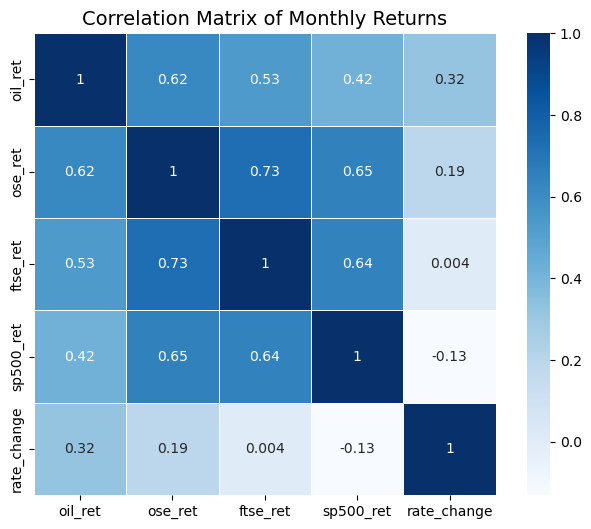

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="Blues", linewidths=0.5, square=True)
plt.title("Correlation Matrix of Monthly Returns", fontsize=14)
plt.show()

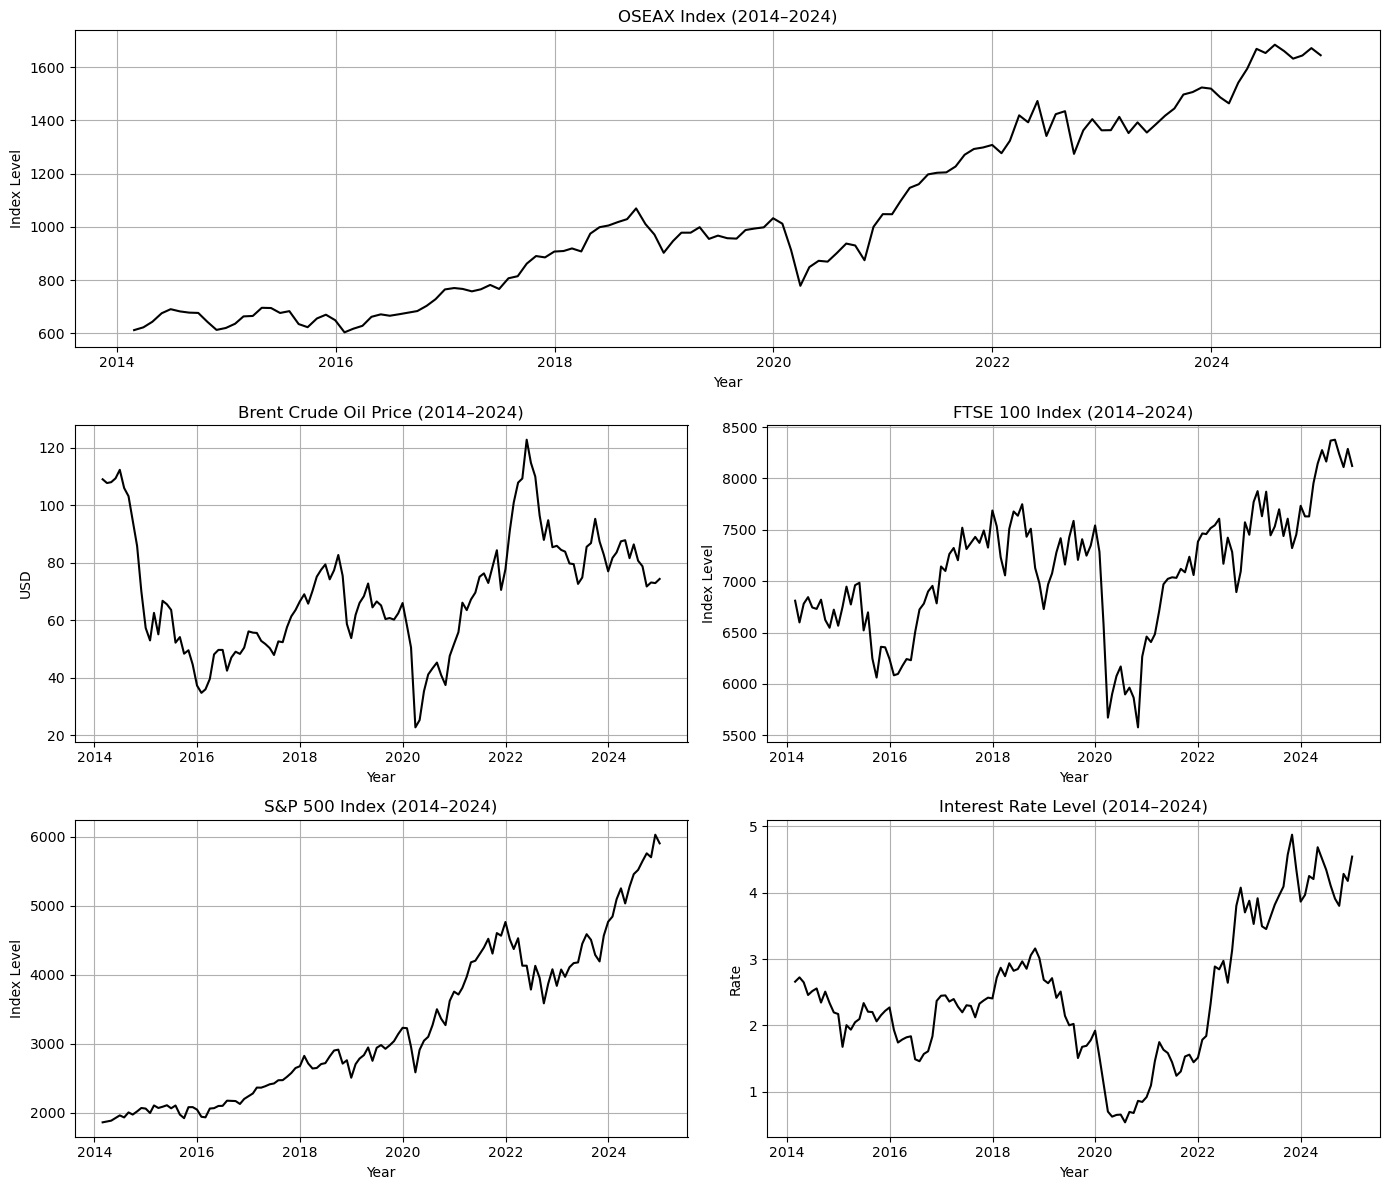

In [14]:
plt.figure(figsize=(14,12))

# OSEAX Inde
plt.subplot(3,1,1) 
plt.plot(df.index, df["ose_price"], color="black")
plt.title("OSEAX Index (2014–2024)")
plt.xlabel("Year")
plt.ylabel("Index Level")
plt.grid(True)


# Brent Oil
plt.subplot(3,2,3)
plt.plot(df.index, df["oil_price"], color="black")
plt.title("Brent Crude Oil Price (2014–2024)")
plt.xlabel("Year")
plt.ylabel("USD")
plt.grid(True)

# FTSE100
plt.subplot(3,2,4)
plt.plot(df.index, df["ftse_price"], color="black")
plt.title("FTSE 100 Index (2014–2024)")
plt.xlabel("Year")
plt.ylabel("Index Level")
plt.grid(True)

# S&P500
plt.subplot(3,2,5)
plt.plot(df.index, df["sp500_price"], color="black")
plt.title("S&P 500 Index (2014–2024)")
plt.xlabel("Year")
plt.ylabel("Index Level")
plt.grid(True)

# Interest Rate
plt.subplot(3,2,6)
plt.plot(df.index, df["rate_level"], color="black")
plt.title("Interest Rate Level (2014–2024)")
plt.xlabel("Year")
plt.ylabel("Rate")
plt.grid(True)

plt.tight_layout()
plt.show()

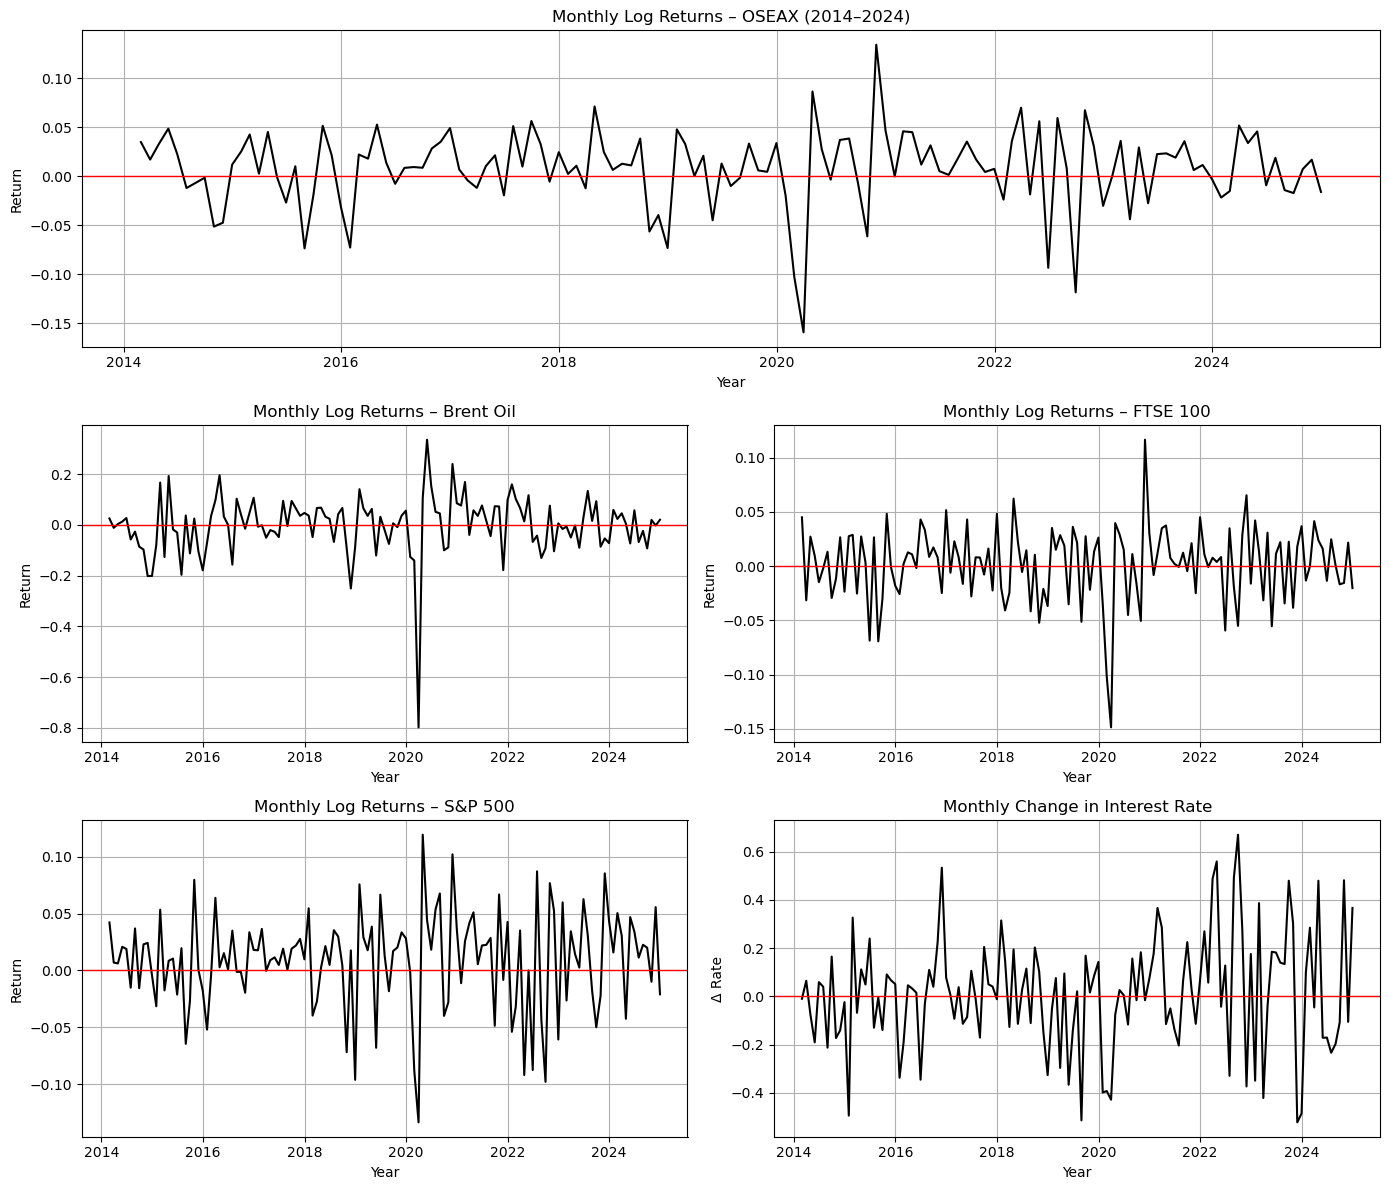

In [15]:
plt.figure(figsize=(14,12))

# OSEAX
plt.subplot(3,1,1)
plt.plot(df.index, df["ose_ret"], color="black")
plt.axhline(0, color="red", linewidth=1)
plt.title("Monthly Log Returns – OSEAX (2014–2024)")
plt.xlabel("Year")
plt.ylabel("Return")
plt.grid(True)

# 1. Oil return
plt.subplot(3,2,3)
plt.plot(df.index, df["oil_ret"], color="black")
plt.axhline(0, color="red", linewidth=1)
plt.title("Monthly Log Returns – Brent Oil")
plt.xlabel("Year")
plt.ylabel("Return")
plt.grid(True)

# 2. FTSE100 return
plt.subplot(3,2,4)
plt.plot(df.index, df["ftse_ret"], color="black")
plt.axhline(0, color="red", linewidth=1)
plt.title("Monthly Log Returns – FTSE 100")
plt.xlabel("Year")
plt.ylabel("Return")
plt.grid(True)

# 3. S&P500 return
plt.subplot(3,2,5)
plt.plot(df.index, df["sp500_ret"], color="black")
plt.axhline(0, color="red", linewidth=1)
plt.title("Monthly Log Returns – S&P 500")
plt.xlabel("Year")
plt.ylabel("Return")
plt.grid(True)

# 4. Interest rate change (ΔRate)
plt.subplot(3,2,6)
plt.plot(df.index, df["rate_change"], color="black")
plt.axhline(0, color="red", linewidth=1)
plt.title("Monthly Change in Interest Rate")
plt.xlabel("Year")
plt.ylabel("Δ Rate")
plt.grid(True)

plt.tight_layout()
plt.show()


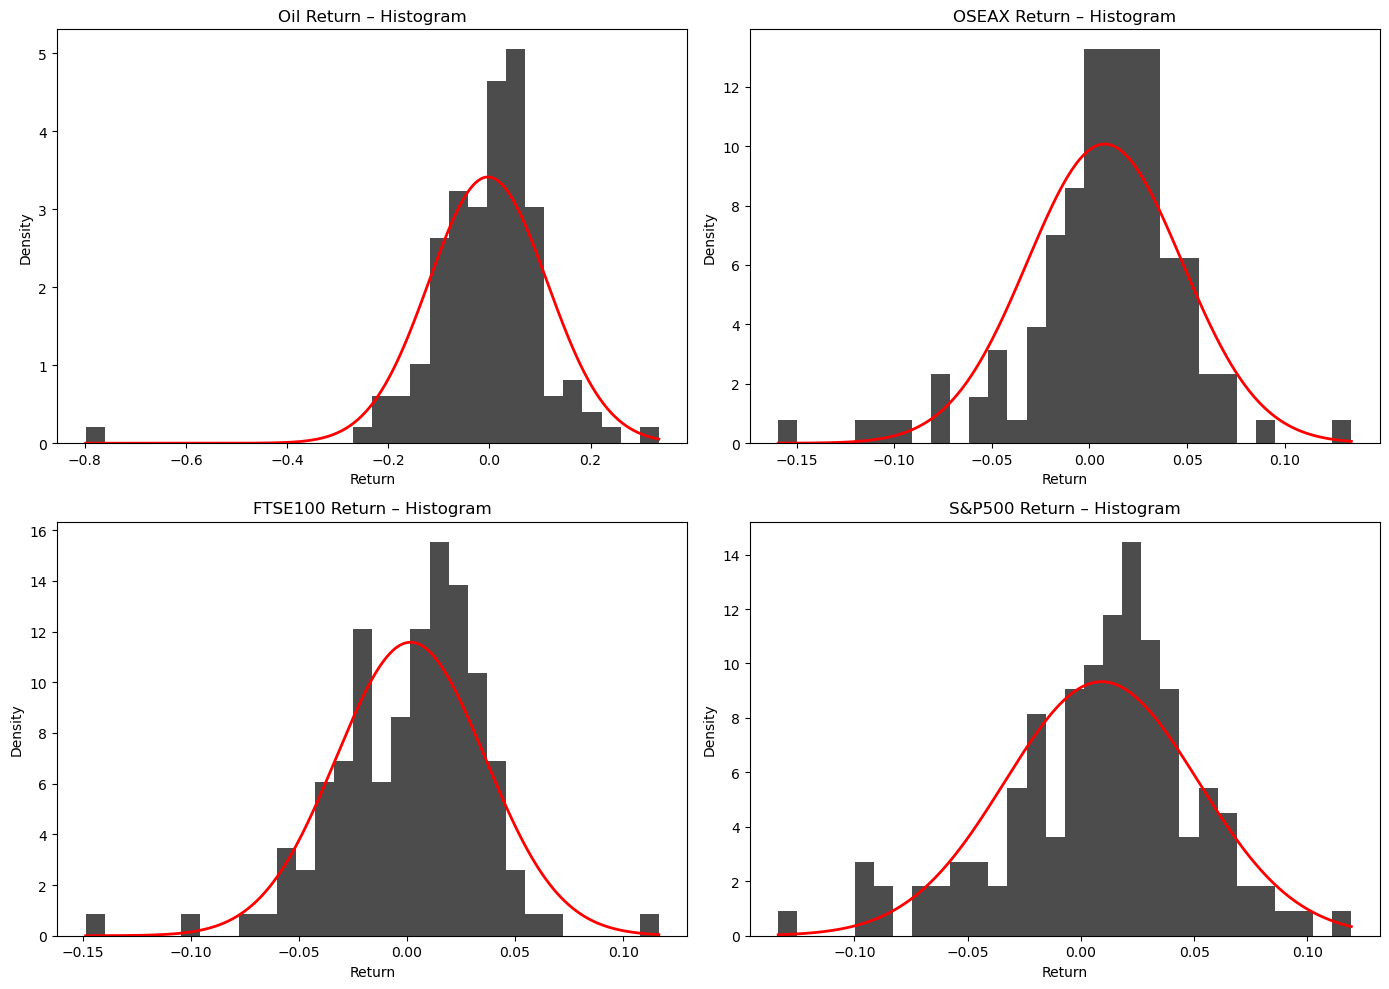

In [16]:
returns = {
    "Oil Return": df["oil_ret"],
    "OSEAX Return": df["ose_ret"],
    "FTSE100 Return": df["ftse_ret"],
    "S&P500 Return": df["sp500_ret"]
}

plt.figure(figsize=(14,10))

for i, (title, series) in enumerate(returns.items(), start=1):
    plt.subplot(2,2,i)
    data = series.dropna()

    # Histogram
    plt.hist(data, bins=30, density=True, color="black", alpha=0.7)

    # Bell curve
    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 300)
    plt.plot(x, norm.pdf(x, mu, sigma), color="red", linewidth=2)

    plt.title(f"{title} – Histogram")
    plt.xlabel("Return")
    plt.ylabel("Density")
    plt.grid(False)

plt.tight_layout()
plt.show()

# 2. OLS Regression Analysis

In [18]:
# Select dependent + independent variables
df_ols = df[["ose_ret", "oil_ret", "ftse_ret", "sp500_ret", "rate_change"]].copy()

# Drop NaN (if any)
df_ols = df_ols.dropna()

# Add constant term (α)
X = sm.add_constant(df_ols[["oil_ret", "ftse_ret", "sp500_ret", "rate_change"]])
y = df_ols["ose_ret"]

# Fit OLS regression model
model = sm.OLS(y, X)
results = model.fit()

# Display full regression summary
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                ose_ret   R-squared:                       0.669
Model:                            OLS   Adj. R-squared:                  0.659
Method:                 Least Squares   F-statistic:                     63.68
Date:                Thu, 18 Dec 2025   Prob (F-statistic):           2.40e-29
Time:                        09:16:37   Log-Likelihood:                 309.99
No. Observations:                 131   AIC:                            -610.0
Df Residuals:                     126   BIC:                            -595.6
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0042      0.002      1.980      

In [19]:
print("\n=== Coefficient Estimates ===")
print(results.params)

print("\n=== Standard Errors ===")
print(results.bse)

print("\n=== 95% Confidence Intervals ===")
print(results.conf_int())

print("\n=== F-statistic:", results.fvalue)
print("F-test p-value:", results.f_pvalue)

print("\n=== R-squared:", results.rsquared)
print("Adjusted R-squared:", results.rsquared_adj)


=== Coefficient Estimates ===
const          0.004183
oil_ret        0.073640
ftse_ret       0.474302
sp500_ret      0.289963
rate_change    0.026626
dtype: float64

=== Standard Errors ===
const          0.002112
oil_ret        0.022597
ftse_ret       0.083289
sp500_ret      0.064364
rate_change    0.009531
dtype: float64

=== 95% Confidence Intervals ===
                    0         1
const        0.000003  0.008363
oil_ret      0.028921  0.118358
ftse_ret     0.309475  0.639129
sp500_ret    0.162588  0.417338
rate_change  0.007764  0.045488

=== F-statistic: 63.677528963303644
F-test p-value: 2.403652963314474e-29

=== R-squared: 0.6690395270490259
Adjusted R-squared: 0.6585328453680426


# 3. Diagnostic Tests

## Residual Setup 

In [22]:
resid = results.resid
resid.describe()

count    1.310000e+02
mean    -2.224684e-18
std      2.279043e-02
min     -7.924804e-02
25%     -1.509078e-02
50%      8.695086e-04
75%      1.652175e-02
max      4.308869e-02
dtype: float64

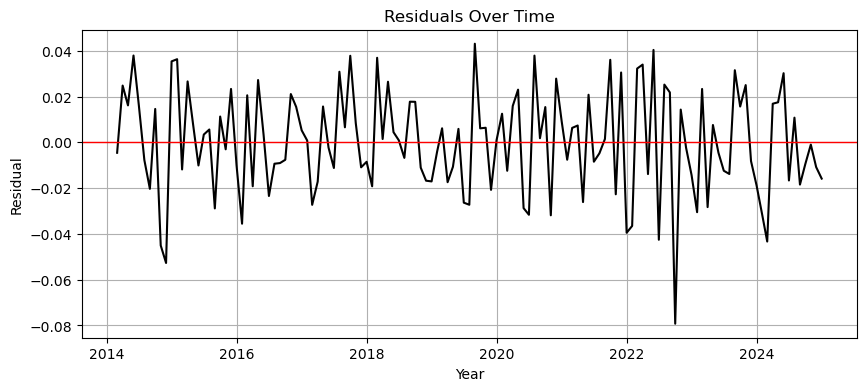

In [23]:
plt.figure(figsize=(10,4))
plt.plot(df_ols.index, resid, color='black')
plt.axhline(0, color='red', linewidth=1)
plt.title("Residuals Over Time")
plt.xlabel("Year")
plt.ylabel("Residual")
plt.grid(True)
plt.show()

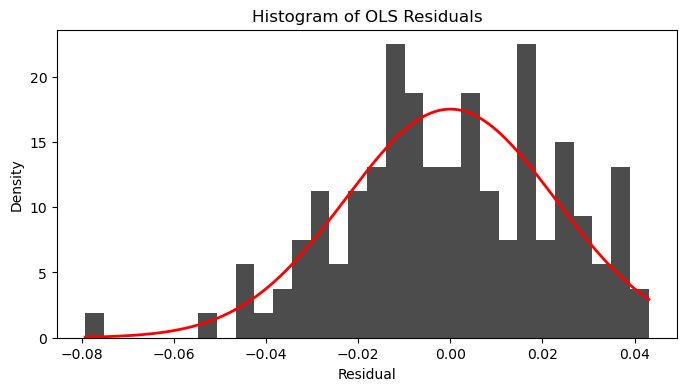

In [24]:
plt.figure(figsize=(8,4))

# Histogram
plt.hist(resid, bins=30, density=True, color="black", alpha=0.7)

# Bell curve (Normal PDF)
mu, sigma = resid.mean(), resid.std()
x = np.linspace(resid.min(), resid.max(), 300)
plt.plot(x, norm.pdf(x, mu, sigma), color="red", linewidth=2)

plt.title("Histogram of OLS Residuals")
plt.xlabel("Residual")
plt.ylabel("Density")
plt.grid(False)
plt.show()

## Normality Test

### Jarque–Bera Test

In [27]:
jb_test = jarque_bera(resid)
print("Jarque-Bera test:", jb_test)

Jarque-Bera test: (2.2576296145817905, 0.3234163400516826, -0.32136904308567, 3.0223446867793804)


## Serial Correlation Tests

### Durbin–Watson

In [30]:
dw = durbin_watson(resid)
print("Durbin–Watson:", dw)

Durbin–Watson: 2.255681150409591


### Ljung–Box Test

In [32]:
lb = acorr_ljungbox(resid, lags=[12], return_df=True)
print(lb)

      lb_stat  lb_pvalue
12  15.099007   0.236067


## Heteroskedascity Tests

### Breusch–Pagan Test

In [35]:
bp_test = het_breuschpagan(resid, results.model.exog)
labels = ['LM-Stat', 'LM p-value', 'F-Stat', 'F p-value']
print(dict(zip(labels, bp_test)))

{'LM-Stat': 6.795061695557434, 'LM p-value': 0.14712280462778995, 'F-Stat': 1.7233166920095269, 'F p-value': 0.14889027581390074}


### White Test (General Heteroskedasticity)

In [37]:
white_test = het_white(resid, results.model.exog)
labels = ['LM-Stat', 'LM p-value', 'F-Stat', 'F p-value']
print(dict(zip(labels, white_test)))

{'LM-Stat': 36.73560621594882, 'LM p-value': 0.0008088654207776265, 'F-Stat': 3.2290107112465263, 'F p-value': 0.00024845186294894885}


## Multicollinearity Check

### VIF

In [40]:
X = df_ols[["oil_ret", "ftse_ret", "sp500_ret", "rate_change"]]
vif_df = pd.DataFrame()
vif_df["Variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_df)

      Variable       VIF
0      oil_ret  1.662918
1     ftse_ret  1.994078
2    sp500_ret  1.786418
3  rate_change  1.212271


# 4. Model Corrections

In [42]:
robust_results = results.get_robustcov_results(cov_type='HC0')
print(robust_results.summary())

                            OLS Regression Results                            
Dep. Variable:                ose_ret   R-squared:                       0.669
Model:                            OLS   Adj. R-squared:                  0.659
Method:                 Least Squares   F-statistic:                     67.56
Date:                Thu, 18 Dec 2025   Prob (F-statistic):           1.97e-30
Time:                        09:16:38   Log-Likelihood:                 309.99
No. Observations:                 131   AIC:                            -610.0
Df Residuals:                     126   BIC:                            -595.6
Df Model:                           4                                         
Covariance Type:                  HC0                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0042      0.002      1.925      

# 5. ARIMA Analysis

### Model Selection

#### Plot ACF & PACF

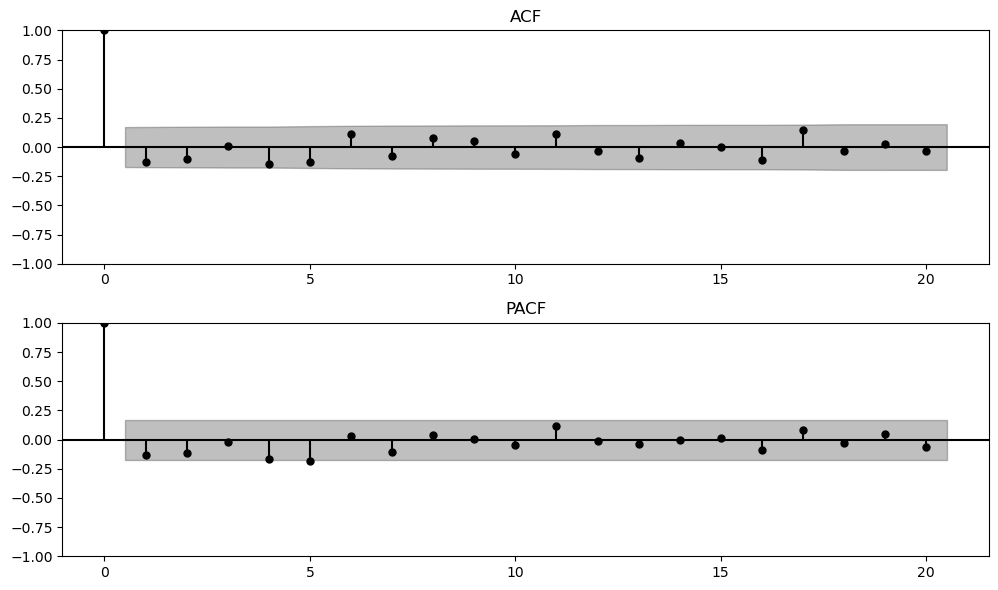

In [103]:
fig, ax = plt.subplots(2, 1, figsize=(10, 6))

# ====================== ACF ======================
plot_acf(resid, lags=20, ax=ax[0])
ax[0].set_title("ACF", fontsize=12)

# ---- recolor CI band (patch) ----
for patch in ax[0].patches:
    patch.set_facecolor("lightgray")
    patch.set_alpha(0.5)

# ---- recolor stems + dots ----
for coll in ax[0].collections:
    coll.set_color("black")          
    coll.set_edgecolor("black")

# ---- recolor lines (baseline etc.) ----
for line in ax[0].lines:
    line.set_color("black")


# ====================== PACF ======================
plot_pacf(resid, lags=20, ax=ax[1])
ax[1].set_title("PACF", fontsize=12)

# ---- recolor CI band ----
for patch in ax[1].patches:
    patch.set_facecolor("lightgray")
    patch.set_alpha(0.5)

# ---- recolor stems + dots ----
for coll in ax[1].collections:
    coll.set_color("black")
    coll.set_edgecolor("black")

# ---- recolor baseline ----
for line in ax[1].lines:
    line.set_color("black")

plt.tight_layout()
plt.show()

#### Automatic AIC Model Selection

In [48]:
import itertools

# search grid
p = q = range(0, 4)
pq = list(itertools.product(p, q))

results_list = []

for order in pq:
    try:
        model = sm.tsa.ARIMA(resid, order=(order[0], 0, order[1])).fit()
        results_list.append([order[0], order[1], model.aic])
    except:
        continue

# Create DataFrame
aic_table = pd.DataFrame(results_list, columns=["AR(p)", "MA(q)", "AIC"])
aic_table = aic_table.sort_values("AIC").reset_index(drop=True)
aic_table.insert(0, "Rank", aic_table.index + 1)
aic_table["AIC"] = aic_table["AIC"].round(3)

# Print as table with borders
print(aic_table.to_markdown(index=False))

|   Rank |   AR(p) |   MA(q) |      AIC |
|-------:|--------:|--------:|---------:|
|      1 |       1 |       1 | -620.51  |
|      2 |       2 |       1 | -618.585 |
|      3 |       1 |       2 | -618.569 |
|      4 |       0 |       2 | -617.803 |
|      5 |       0 |       1 | -616.847 |
|      6 |       0 |       3 | -616.722 |
|      7 |       3 |       1 | -616.622 |
|      8 |       1 |       0 | -616.192 |
|      9 |       2 |       0 | -616.039 |
|     10 |       0 |       0 | -615.973 |
|     11 |       1 |       3 | -615.422 |
|     12 |       2 |       2 | -614.761 |
|     13 |       2 |       3 | -614.636 |
|     14 |       3 |       2 | -614.625 |
|     15 |       3 |       3 | -614.368 |
|     16 |       3 |       0 | -614.091 |


In [49]:
arima_model = sm.tsa.ARIMA(resid, order=(1,0,1)).fit()
print(arima_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  131
Model:                 ARIMA(1, 0, 1)   Log Likelihood                 314.255
Date:                Thu, 18 Dec 2025   AIC                           -620.510
Time:                        09:16:39   BIC                           -609.010
Sample:                    02-28-2014   HQIC                          -615.837
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.276e-05      0.001     -0.026      0.979      -0.002       0.002
ar.L1          0.6576      0.158      4.164      0.000       0.348       0.967
ma.L1         -0.8587      0.119     -7.200      0.0

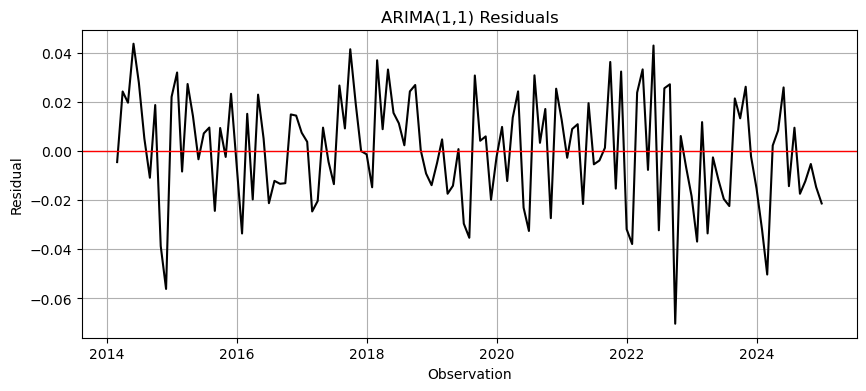

In [50]:
plt.figure(figsize=(10,4))
plt.plot(arima_model.resid, color="black")
plt.axhline(0, color="red", linewidth=1)
plt.title("ARIMA(1,1) Residuals")
plt.xlabel("Observation")
plt.ylabel("Residual")
plt.grid(True)
plt.show()